# 📦 Notebook 06: Entrenamiento YOLO26n para ESP32-S3

Este notebook implementa el pipeline completo de entrenamiento del modelo **YOLO26n** 
para detección de objetos en tiempo real, optimizado para deployment en **ESP32-S3**.

## Características de YOLO26:
- 🎯 **NMS-free** (end-to-end): Inferencia simplificada sin post-procesado
- 🚀 **DFL-free**: Mejor cuantización INT8 para edge deployment
- ⚡ **MuSGD optimizer**: Convergencia estable automática
- 📊 **ProgLoss + STAL**: Mejora detección de objetos pequeños
- 🔥 **43% más rápido** en CPU que YOLO11

## Estructura del Notebook:
1. Setup y Configuración
2. Configuración del Experimento
3. Conversión Dataset COCO → YOLO
4. Análisis de Distribución de Clases
5. Configuración de Entrenamiento
6. Entrenamiento del Modelo
7. Extracción y Visualización de Métricas
8. Evaluación en Test Set
9. Exportación a TFLite INT8
10. Comparación Keras vs TFLite
11. Guardado de Resultados
12. Comparación de Experimentos

## 1. Setup y Configuración

In [1]:
# ============================================================================
# SECCIÓN 1: SETUP Y CONFIGURACIÓN
# ============================================================================

import os
import sys
from pathlib import Path
import warnings

# Suprimir warnings generales
warnings.filterwarnings('ignore')

# -------------------------------------------------------------------------
# Configuración PyTorch/CUDA/MPS (usado por YOLO26/Ultralytics)
# -------------------------------------------------------------------------
import torch

# Detectar dispositivo disponible (CUDA para NVIDIA, MPS para Apple Silicon)
if torch.cuda.is_available():
    DEVICE = "cuda"
    gpu_name = torch.cuda.get_device_name(0)
    gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"✅ GPU detectada (CUDA): {gpu_name} ({gpu_memory:.1f} GB)")
elif torch.backends.mps.is_available():
    DEVICE = "mps"
    print("✅ GPU detectada (MPS - Apple Silicon)")
    print("   💡 Metal Performance Shaders habilitado para aceleración")
else:
    DEVICE = "cpu"
    print("⚠️ GPU no disponible - entrenamiento en CPU (será lento)")

print(f"   🖥️ Dispositivo PyTorch: {DEVICE}")

# -------------------------------------------------------------------------
# Configuración TensorFlow (solo para exportación TFLite en Sección 9)
# -------------------------------------------------------------------------
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suprimir logs verbosos de TF

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ TensorFlow: memory growth habilitado para {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(f"⚠️ TensorFlow GPU config: {e}")

# Configurar paths
NOTEBOOK_DIR = Path(os.getcwd())
PROJECT_ROOT = NOTEBOOK_DIR.parent
SRC_PATH = PROJECT_ROOT

# Añadir src_yolo al path
sys.path.insert(0, str(SRC_PATH))

# Verificar estructura de directorios
print("\n📁 Estructura del proyecto:")
print(f"   Notebook: {NOTEBOOK_DIR}")
print(f"   Project:  {PROJECT_ROOT}")
print(f"   Src:      {SRC_PATH}")

# Verificar que src_yolo existe
YOLO_SRC = SRC_PATH / "src_yolo"
if YOLO_SRC.exists():
    print(f"\n✅ src_yolo encontrado en: {YOLO_SRC}")
else:
    print(f"\n❌ src_yolo NO encontrado - verificar estructura")

# Imports de utilidades YOLO26
from src_yolo import (
    # IO
    safe_mkdir, safe_exists,
    # Data
    create_yolo_dataset, get_class_distribution, calculate_class_weights,
    # Model
    load_yolo26_model, print_model_summary,
    check_ultralytics_version, check_yolo26_features, YOLO26_SPECS,
    # Training
    Yolo26TrainConfig, train_yolo26,
    # Metrics
    extract_yolo_metrics, plot_yolo_history, get_best_metrics,
    # Export
    export_tflite_int8, verify_tflite_model, estimate_model_size,
    compare_keras_vs_tflite,
    # Eval
    evaluate_model, plot_confusion_matrix,
    # Experiment
    Yolo26ExperimentConfig, Yolo26ExperimentResults, Yolo26Experiment,
    save_experiment, load_all_experiments, compare_experiments,
)

print("\n✅ Imports de src_yolo completados")

# Verificar versión de Ultralytics
ultralytics_version = check_ultralytics_version()
print(f"\n📦 Ultralytics {ultralytics_version} listo para entrenamiento YOLO26")

✅ GPU detectada (MPS - Apple Silicon)
   💡 Metal Performance Shaders habilitado para aceleración
   🖥️ Dispositivo PyTorch: mps
✅ TensorFlow: memory growth habilitado para 1 GPU(s)

📁 Estructura del proyecto:
   Notebook: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/notebooks
   Project:  /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS
   Src:      /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS

✅ src_yolo encontrado en: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/src_yolo

✅ Imports de src_yolo completados
✅ Ultralytics version: 8.4.9
   ✅ Compatible con YOLO26 (end2end, DFL-free)

📦 Ultralytics 8.4.9 listo para entrenamiento YOLO26


## 2. Configuración del Experimento

In [2]:
# ============================================================================
# SECCIÓN 2A: CONFIGURACIÓN DEL EXPERIMENTO
# ============================================================================
# Modificar estos valores para cada experimento.

# Configuración del modelo YOLO26
MODEL_VARIANT = "yolo26n"  # Variante más pequeña para ESP32
IMGSZ = 224  # Tamaño de imagen para ESP32-S3

# Definir versión del experimento
VERSION = "v1"
EXPERIMENT_NAME = f"{MODEL_VARIANT}_{VERSION}"
DESCRIPTION = """Primer entrenamiento real YOLO26n para ESP32-S3.
Objetivo: Superar MobileNetV3 baseline (mAP@50=0.606).
Configuración optimizada basada en análisis de dataset:
- obstacle: 68% de anotaciones, 20% objetos pequeños
- footpath: 32% de anotaciones, 62% objetos grandes
- Desbalance 2.1:1 obstacle/footpath"""

EXPERIMENT_NOTES = """
Análisis del problema:
1. Dataset: 2,432 anotaciones (obstacle:1648, footpath:784)
2. Desbalance de clases: 2.1:1 a favor de obstacle
3. obstacle tiene 20% de objetos pequeños (<32x32) vs 3% en footpath
4. obstacle tiene área mediana 4,123px² vs 11,399px² en footpath

Configuración justificada:
- EPOCHS=150: Suficiente para convergencia, dataset mediano (~1,400 imgs)
- LR0=0.01: Default Ultralytics, mayor que v0 para mejor convergencia
- MOSAIC=1.0: Máximo para mejorar detección de objetos pequeños (obstacle)
- MIXUP=0.15: Bajo-moderado, regularización sin confusión
- CLS_LOSS_WEIGHT=1.0: Aumentado para mejorar clasificación (problema en MobileNetV3)
- SCALE=0.5: ±50% escala para variabilidad de tamaños de obstacle

Objetivos:
- mAP@50 (Keras) ≥ 0.65 (vs 0.606 MobileNetV3)
- mAP@50 (TFLite) ≥ 0.60 (vs 0.574 MobileNetV3)
- Precision ≥ 0.50 (vs 0.204 MobileNetV3)
- Recall ≥ 0.55 (vs 0.419 MobileNetV3)
- F1 ≥ 0.52 (vs 0.274 MobileNetV3)
""".strip()

# Clases del dataset (orden alfabético para consistencia)
CLASS_NAMES = ["footpath", "obstacle"]
NUM_CLASSES = len(CLASS_NAMES)

# --- Umbrales de evaluación e inferencia ---
CONF_THRESHOLD = 0.25  # Umbral de confianza para detecciones
IOU_THRESHOLD = 0.5    # Umbral IoU para NMS y matching (estándar COCO)

# --- Entrenamiento ---
EPOCHS = 150            # Épocas suficientes para convergencia
PATIENCE = 30           # Early stopping moderado (evita overfitting)
BATCH_SIZE = 16         # Óptimo para MPS con IMGSZ=224

# --- Optimizador ---
OPTIMIZER = "MuSGD"      # 'auto' selecciona MuSGD para YOLO26 (recomendado)
LR0 = 0.01              # Learning rate inicial (default Ultralytics)
LRF = 0.01              # Factor final: lr_final = lr0 * lrf = 0.0001
COS_LR = True           # Decaimiento coseno (suave y efectivo)

# --- Augmentación (optimizada para objetos pequeños) ---
MOSAIC = 1.0            # Máximo: combina 4 imágenes, mejora small objects
MIXUP = 0.15            # Bajo-moderado: regularización sin confusión
CLOSE_MOSAIC = 15       # Desactivar mosaic últimas 15 épocas (estabiliza)
SCALE = 0.5             # ±50% escala: crítico para obstacle (tamaños variables)
FLIPLR = 0.5            # Flip horizontal estándar

# --- Pesos de Pérdida ---
BOX_LOSS_WEIGHT = 7.5   # Peso de bounding box (default Ultralytics)
CLS_LOSS_WEIGHT = 1.0   # Aumentado: mejorar clasificación (problema MobileNetV3)

# --- YOLO26 Específico ---
MAX_DET = 300           # Máximo detecciones por imagen (end2end head)


In [3]:
# ============================================================================
# SECCIÓN 2B: RUTAS DE DATOS Y DIRECTORIOS
# ============================================================================

# --- Rutas del proyecto ---
ING_DATOS = PROJECT_ROOT.parent / "01_ING_DATOS"

# --- Rutas del Dataset COCO (originales) ---
COCO_TRAIN_JSON = ING_DATOS / "Dataset/train/augmented2_images/train_final2.json"
COCO_VAL_JSON = ING_DATOS / "Dataset/valid/val_final.json"
COCO_TEST_JSON = ING_DATOS / "Dataset/test/test_final.json"

# --- Paths de salida ---
YOLO_DATASET_DIR = PROJECT_ROOT / "datasets" / "yolo26"
MODELS_DIR = PROJECT_ROOT / "models"
LOGS_DIR = PROJECT_ROOT / "logs"
REPORTS_DIR = PROJECT_ROOT / "reports" / EXPERIMENT_NAME
EXPERIMENTS_DIR = LOGS_DIR / "experiments"

# Crear directorios
for dir_path in [YOLO_DATASET_DIR, MODELS_DIR, LOGS_DIR, REPORTS_DIR, EXPERIMENTS_DIR]:
    safe_mkdir(str(dir_path))


In [4]:
# ============================================================================
# SECCIÓN 2C: RESUMEN DE CONFIGURACIÓN
# ============================================================================

# --- Resumen de Configuración ---
print("\n🔬 CONFIGURACIÓN DEL EXPERIMENTO")
print(f"📋 Nombre: {EXPERIMENT_NAME}")

print("\n📁 Paths:")
print(f"   Dataset COCO (train): {COCO_TRAIN_JSON}")
print(f"   Dataset COCO (val):   {COCO_VAL_JSON}")
print(f"   Dataset COCO (test):  {COCO_TEST_JSON}")
print(f"   Dataset YOLO:         {YOLO_DATASET_DIR}")
print(f"   Modelos:              {MODELS_DIR}")
print(f"   Logs:                 {LOGS_DIR}")

# Verificar existencia del dataset
print("\n📂 Verificando archivos JSON:")
for json_path in [COCO_TRAIN_JSON, COCO_VAL_JSON, COCO_TEST_JSON]:
    if safe_exists(str(json_path)):
        print(f"   ✅ {json_path.name}")
    else:
        print(f"   ❌ {json_path.name} - NO ENCONTRADO")


print("\n⚙️ HIPERPARÁMETROS DE ENTRENAMIENTO")
print(f"📊 Entrenamiento:")
print(f"   Epochs:     {EPOCHS}")
print(f"   Patience:   {PATIENCE}")
print(f"   Batch size: {BATCH_SIZE}")

print(f"\n🎯 Optimizador:")
print(f"   Optimizer:  {OPTIMIZER}")
print(f"   LR inicial: {LR0}")
print(f"   LR final:   {LR0 * LRF:.6f} (lr0 × lrf)")
print(f"   Cosine LR:  {COS_LR}")

print(f"\n🔄 Augmentación:")
print(f"   Mosaic:     {MOSAIC}")
print(f"   Mixup:      {MIXUP}")
print(f"   Scale:      ±{SCALE*100:.0f}%")
print(f"   Flip LR:    {FLIPLR}")

print(f"\n⚖️ Loss Weights:")
print(f"   Box:        {BOX_LOSS_WEIGHT}")
print(f"   Cls:        {CLS_LOSS_WEIGHT}")

print(f"\n🤖 Umbrales para evaluación y predicción:")
print(f"   Conf threshold: {CONF_THRESHOLD}")
print(f"   IoU threshold:  {IOU_THRESHOLD}")


🔬 CONFIGURACIÓN DEL EXPERIMENTO
📋 Nombre: yolo26n_v1

📁 Paths:
   Dataset COCO (train): /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Dataset/train/augmented2_images/train_final2.json
   Dataset COCO (val):   /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Dataset/valid/val_final.json
   Dataset COCO (test):  /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Dataset/test/test_final.json
   Dataset YOLO:         /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/datasets/yolo26
   Modelos:              /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models
   Logs:                 /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs

📂 Verificando archivos JSON:
   ✅ train_final2.json
   ✅ val_final.json
   ✅ test_final.json

⚙️ HIPERPARÁMETROS DE ENTRENAMIENTO
📊 Entrenamiento:
   Epochs:     150
   Patience:   30
   Batch size: 16

🎯 Optimizador:
   Optimizer:  MuSGD
   LR inicial: 0.01
   LR final:   0.000100 (lr0 × lrf)
   Cosine LR:  True

🔄 Augmentación:
   Mosaic:     1.0
   Mixup:      0.15
  

## 3. Conversión Dataset COCO → YOLO

In [5]:
# ============================================================================
# SECCIÓN 3A: CONVERSIÓN DATASET COCO → YOLO
# ============================================================================

# Convertir dataset de COCO a formato YOLO
# Esto crea la estructura:
#   datasets/yolo26/
#   ├── images/
#   │   ├── train/
#   │   ├── val/
#   │   └── test/
#   ├── labels/
#   │   ├── train/
#   │   ├── val/
#   │   └── test/
#   └── data.yaml

data_yaml_path = create_yolo_dataset(
    coco_train_json=str(COCO_TRAIN_JSON),
    coco_val_json=str(COCO_VAL_JSON),
    coco_test_json=str(COCO_TEST_JSON),
    output_dir=str(YOLO_DATASET_DIR),
    class_names=CLASS_NAMES,
    copy_images=True,  # Copiar imágenes al nuevo directorio
    verbose=True,
)

if data_yaml_path:
    DATA_YAML = data_yaml_path
    print(f"\n✅ Dataset YOLO creado exitosamente")
    print(f"   data.yaml: {DATA_YAML}")
else:
    print("❌ Error creando dataset YOLO")


🔧 CREANDO DATASET YOLO26
📁 Destino: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/datasets/yolo26
🗑️ Directorio existente eliminado

🔄 Procesando subset: TRAIN...
   🔍 Filtrando a 2 clases: ['footpath', 'obstacle']
   📋 Categorías originales en JSON: [(2, 'door'), (5, 'footpath'), (6, 'obstacle'), (7, 'person')]
   📋 Categorías seleccionadas: {5: 'footpath', 6: 'obstacle'}
   🔗 Mapeo de IDs: {5: 0, 6: 1}
   ✅ Nombres de clase (ordenados): ['footpath', 'obstacle']
   ✅ 1371 imágenes procesadas, 0 omitidas
   🔍 804 anotaciones filtradas (clases excluidas)
   📊 Distribución: {'footpath': 784, 'obstacle': 1648}

🔄 Procesando subset: VAL...
   🔍 Filtrando a 2 clases: ['footpath', 'obstacle']
   📋 Categorías originales en JSON: [(2, 'door'), (5, 'footpath'), (6, 'obstacle'), (7, 'person')]
   📋 Categorías seleccionadas: {5: 'footpath', 6: 'obstacle'}
   🔗 Mapeo de IDs: {5: 0, 6: 1}
   ✅ Nombres de clase (ordenados): ['footpath', 'obstacle']
   ✅ 85 imágenes procesadas, 0 omitidas
   🔍 25 a

In [6]:
# ============================================================================
# SECCIÓN 3B: VERIFICACIÓN DE LABELS YOLO
# ============================================================================

# Verificar que los labels se generaron correctamente
# Esto confirma que el mapeo de clases es correcto:
#   - Los índices en los .txt corresponden a CLASS_NAMES
#   - Las coordenadas están normalizadas (0-1)
#   - La distribución de clases es la esperada

from src_yolo import verify_yolo_labels

verification = verify_yolo_labels(
    yolo_root=str(YOLO_DATASET_DIR),
    class_names=CLASS_NAMES,
    num_samples=3,  # Mostrar 3 archivos de ejemplo por split
    verbose=True,
)

# Guardar resultado para uso posterior
if not verification["valid"]:
    print("\n⚠️ ATENCIÓN: Se detectaron errores en los labels.")
    print("   Revisa los mensajes anteriores antes de continuar.")


🔍 VERIFICACIÓN DE LABELS YOLO
   📂 Dataset: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/datasets/yolo26
   🏷️ Clases esperadas (2): ['footpath', 'obstacle']

   📁 TRAIN:
      Imágenes: 1371
      Bounding boxes: 2432
      Distribución por clase:
         [0] footpath: 784 (32.2%)
         [1] obstacle: 1648 (67.8%)

      📋 Muestra de 3 labels:
         20250419_202930_jpg.rf.3722d425d66dbc5a7045815173a307db.txt:
            idx=1 → 'obstacle' | bbox=[0.7008, 0.4419, 0.0892, 0.1160]
            idx=1 → 'obstacle' | bbox=[0.6763, 0.5491, 0.1116, 0.1250]
            idx=1 → 'obstacle' | bbox=[0.8560, 0.6852, 0.2745, 0.1383]
            ... (1 más)
         ikea-a-sunny-space-for-celebrating-or-just-having-breakfast__1364308409238-s4_jpg.rf.a2ad525218b53e5c0f607ddd0ae2a5ba.txt:
            idx=1 → 'obstacle' | bbox=[0.5044, 0.6919, 0.7767, 0.5089]
         aug2_2_20250420_150821_jpg.rf.144123a8e20a6bae66012eab5dd62b2a.txt:
            idx=1 → 'obstacle' | bbox=[0.5929, 0.6081, 0.433

## 4. Análisis de Distribución de Clases

📊 Distribución de Clases Seleccionadas (Train Set):
   Clases filtradas: ['footpath', 'obstacle']
----------------------------------------
   obstacle      1648 ( 67.8%) █████████████████████████████████
   footpath       784 ( 32.2%) ████████████████
----------------------------------------
   Total: 2432 objetos (de 3236 en dataset completo)

⚖️ Class Weights (para pérdida ponderada):
   footpath: 1.355
   obstacle: 0.645


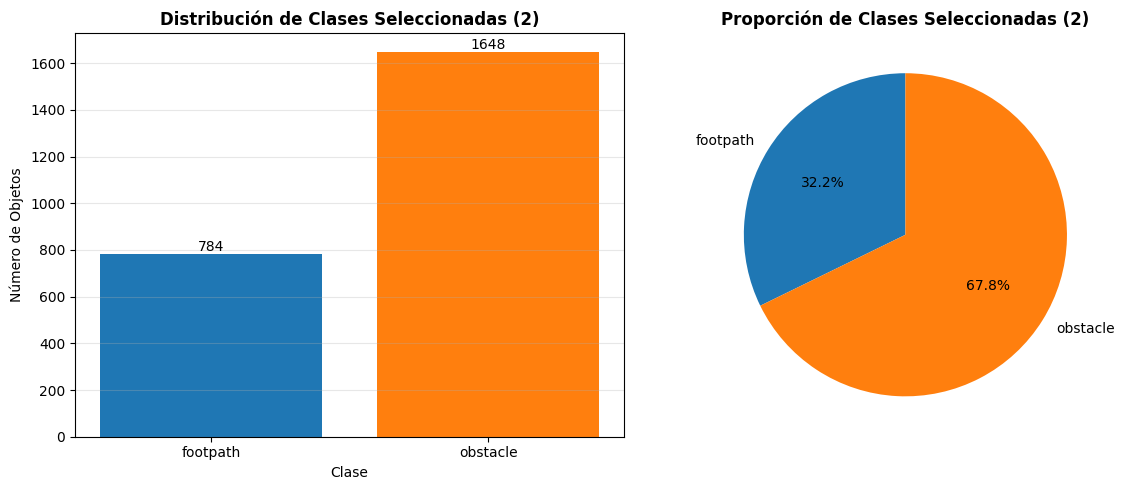

In [7]:
# ============================================================================
# SECCIÓN 4: ANÁLISIS DE DISTRIBUCIÓN DE CLASES
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np

# Obtener distribución de clases del dataset de entrenamiento
class_dist_full = get_class_distribution(str(COCO_TRAIN_JSON))

if class_dist_full:
    # Filtrar solo las clases seleccionadas en CLASS_NAMES
    class_dist = {k: v for k, v in class_dist_full.items() if k in CLASS_NAMES}
    
    # Verificar que todas las clases solicitadas existen en el dataset
    missing_classes = [c for c in CLASS_NAMES if c not in class_dist_full]
    if missing_classes:
        print(f"⚠️ Clases no encontradas en dataset: {missing_classes}")
    
    print(f"📊 Distribución de Clases Seleccionadas (Train Set):")
    print(f"   Clases filtradas: {CLASS_NAMES}")
    print("-" * 40)
    total = sum(class_dist.values())
    for cls_name, count in sorted(class_dist.items(), key=lambda x: x[1], reverse=True):
        pct = (count / total) * 100
        bar = "█" * int(pct / 2)
        print(f"   {cls_name:<12} {count:>5} ({pct:>5.1f}%) {bar}")
    print("-" * 40)
    print(f"   Total: {total} objetos (de {sum(class_dist_full.values())} en dataset completo)")
    
    # Calcular class weights para manejo de desbalance (solo clases filtradas)
    class_weights = calculate_class_weights(class_dist, CLASS_NAMES)
    print("\n⚖️ Class Weights (para pérdida ponderada):")
    for cls_name, weight in class_weights.items():
        print(f"   {cls_name}: {weight:.3f}")
    
    # Visualizar distribución (solo clases seleccionadas)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Bar chart
    ax = axes[0]
    classes = list(class_dist.keys())
    counts = list(class_dist.values())
    colors = plt.cm.tab10.colors[:len(classes)]
    bars = ax.bar(classes, counts, color=colors)
    ax.set_title(f"Distribución de Clases Seleccionadas ({len(CLASS_NAMES)})", 
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Clase")
    ax.set_ylabel("Número de Objetos")
    ax.grid(True, alpha=0.3, axis="y")
    for bar, count in zip(bars, counts):
        ax.annotate(f"{count}", xy=(bar.get_x() + bar.get_width()/2, count),
                    ha="center", va="bottom", fontsize=10)
    
    # Pie chart
    ax = axes[1]
    ax.pie(counts, labels=classes, autopct="%1.1f%%", colors=colors, startangle=90)
    ax.set_title(f"Proporción de Clases Seleccionadas ({len(CLASS_NAMES)})", 
                 fontsize=12, fontweight="bold")
    
    plt.tight_layout()
    plt.savefig(str(REPORTS_DIR / f"{EXPERIMENT_NAME}_class_distribution.png"), dpi=150)
    plt.show()
else:
    print("⚠️ No se pudo obtener la distribución de clases")

## 5. Configuración de Entrenamiento YOLO26

In [8]:
# ============================================================================
# SECCIÓN 5: CONFIGURACIÓN DE ENTRENAMIENTO YOLO26
# ============================================================================

# Mostrar especificaciones de variantes YOLO26
print("📋 Especificaciones YOLO26 disponibles:")
print("-" * 70)
print(f"{'Variante':<12} {'Params':>10} {'GFLOPs':>10} {'mAP50':>10} {'mAP50-95':>12}")
print("-" * 70)
for variant, specs in YOLO26_SPECS.items():
    print(f"{variant:<12} {specs['params']:<10} {specs['gflops']:<10} "
          f"{specs['map50']:>10.1f} {specs['map50_95']:>12.1f}")
print("-" * 70)
print(f"\n🎯 Seleccionado: {MODEL_VARIANT}")

# Crear configuración de entrenamiento
train_config = Yolo26TrainConfig(
    # Modelo (de Sección 2)
    model=f"{MODEL_VARIANT}.pt",
    imgsz=IMGSZ,
    
    # Entrenamiento (de Sección 2B)
    epochs=EPOCHS,
    patience=PATIENCE,
    batch=BATCH_SIZE,
    
    # Optimizador (de Sección 2B)
    optimizer=OPTIMIZER,
    lr0=LR0,
    lrf=LRF,
    cos_lr=COS_LR,
    
    # Augmentación (de Sección 2B)
    mosaic=MOSAIC,
    mixup=MIXUP,
    close_mosaic=CLOSE_MOSAIC,
    scale=SCALE,
    fliplr=FLIPLR,
    
    # Loss weights (de Sección 2B)
    box=BOX_LOSS_WEIGHT,
    cls=CLS_LOSS_WEIGHT,

    # YOLO26 específico (de Sección 2B)
    max_det=MAX_DET,
    
    # Proyecto
    project=str(LOGS_DIR),
    name=EXPERIMENT_NAME,
    exist_ok=True,
)

# Mostrar resumen de configuración
print(train_config.summary())

# Verificar características YOLO26
print("\n🔍 Verificando características YOLO26...")
check_yolo26_features()

📋 Especificaciones YOLO26 disponibles:
----------------------------------------------------------------------
Variante         Params     GFLOPs      mAP50     mAP50-95
----------------------------------------------------------------------
yolo26n      2.4M       5.4              40.9         40.1
yolo26s      9.5M       20.7             48.6         47.8
yolo26m      20.4M      68.2             53.1         52.5
yolo26l      24.8M      86.4             55.0         54.4
yolo26x      55.7M      193.9            57.5         56.9
----------------------------------------------------------------------

🎯 Seleccionado: yolo26n
🔧 CONFIGURACIÓN DE ENTRENAMIENTO YOLO26
📦 Modelo: yolo26n.pt
📐 Imagen: 224x224

⏱️ Entrenamiento:
   Épocas: 150 | Paciencia: 30
   Batch: 16 | Workers: 8

🎯 Optimizador:
   Tipo: MuSGD (MuSGD para YOLO26)
   LR inicial: 0.01 → final: 0.0001
   Cosine LR: True

🔄 Augmentación:
   Mosaic: 1.0 | Mixup: 0.15
   Close mosaic: 15 épocas
   Scale: 0.5 | Flip LR: 0.5

⚖️ Lo

{'ultralytics_available': True,
 'yolo26_available': True,
 'end2end_available': True,
 'tflite_export': True,
 'int8_quantization': True}

In [9]:
# ============================================================================
# SECCIÓN 6: ENTRENAMIENTO DEL MODELO
# ============================================================================

# Iniciar entrenamiento
# YOLO26 usa:
# - MuSGD optimizer (auto-seleccionado)
# - ProgLoss + STAL para mejor detección de objetos pequeños
# - End-to-end training (sin fases separadas)

print("🚀 Iniciando entrenamiento YOLO26n...")
print("⏱️ Tiempo estimado: ~30-60 minutos (GPU) / 2-4 horas (CPU)")
print()

# Entrenar modelo
training_results = train_yolo26(
    data_yaml=DATA_YAML,
    cfg=train_config,
    resume=False,
)

if training_results:
    print("\n✅ Entrenamiento completado exitosamente")
    RESULTS_DIR = str(LOGS_DIR / EXPERIMENT_NAME)
else:
    print("\n⚠️ El entrenamiento tuvo problemas - verificar logs")
    RESULTS_DIR = None

🚀 Iniciando entrenamiento YOLO26n...
⏱️ Tiempo estimado: ~30-60 minutos (GPU) / 2-4 horas (CPU)


🔧 CONFIGURACIÓN DE ENTRENAMIENTO YOLO26
📦 Modelo: yolo26n.pt
📐 Imagen: 224x224

⏱️ Entrenamiento:
   Épocas: 150 | Paciencia: 30
   Batch: 16 | Workers: 8

🎯 Optimizador:
   Tipo: MuSGD (MuSGD para YOLO26)
   LR inicial: 0.01 → final: 0.0001
   Cosine LR: True

🔄 Augmentación:
   Mosaic: 1.0 | Mixup: 0.15
   Close mosaic: 15 épocas
   Scale: 0.5 | Flip LR: 0.5

⚖️ Loss Weights:
   Box: 7.5 | Cls: 1.0

📁 Proyecto: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/yolo26n_v1
🔄 Cargando modelo base: yolo26n.pt

🚀 Iniciando entrenamiento YOLO26...
   💡 YOLO26 usa MuSGD optimizer y entrenamiento end-to-end
   💡 ProgLoss + STAL activos para mejor detección de objetos pequeños
   💡 Modelo NMS-free para deployment simplificado

New https://pypi.org/project/ultralytics/8.4.11 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.9 🚀 Python-3.10.19 torch-2.5.1 CPU (Apple M1)
engine/

In [10]:
# ============================================================================
# SECCIÓN 6B: RECUPERACIÓN DE ENTRENAMIENTO INTERRUMPIDO
# ============================================================================
# Ejecutar esta celda si el entrenamiento fue interrumpido pero el modelo best.pt existe

RESULTS_DIR = str(LOGS_DIR / EXPERIMENT_NAME)

# Verificar que el modelo existe
BEST_MODEL_PATH = str(LOGS_DIR / EXPERIMENT_NAME / "weights" / "best.pt")

if safe_exists(BEST_MODEL_PATH):
    print(f"✅ Modelo best.pt encontrado: {BEST_MODEL_PATH}")
    print(f"   📂 Results dir: {RESULTS_DIR}")
    print("\n💡 Puedes continuar con la Sección 7 (Extracción de Métricas)")
else:
    print(f"❌ Modelo no encontrado: {BEST_MODEL_PATH}")

✅ Modelo best.pt encontrado: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/yolo26n_v1/weights/best.pt
   📂 Results dir: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/yolo26n_v1

💡 Puedes continuar con la Sección 7 (Extracción de Métricas)


## 7. Extracción y Visualización de Métricas

✅ Historial guardado en: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/yolo26n_v1_history.csv
✅ Mejor modelo: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/models/checkpoints/yolo26n_v1_best.pt
   📦 Tamaño: 14.78 MB | INT8 estimado: ~3.70 MB

📊 Métricas extraídas exitosamente
   Épocas completadas: 89

🏆 Mejores métricas:
   best_mAP50: 0.7333
   best_mAP50-95: 0.4282
   best_precision: 0.8875
   best_recall: 0.8799
   best_box_loss: 1.4492
   best_cls_loss: 2.4337


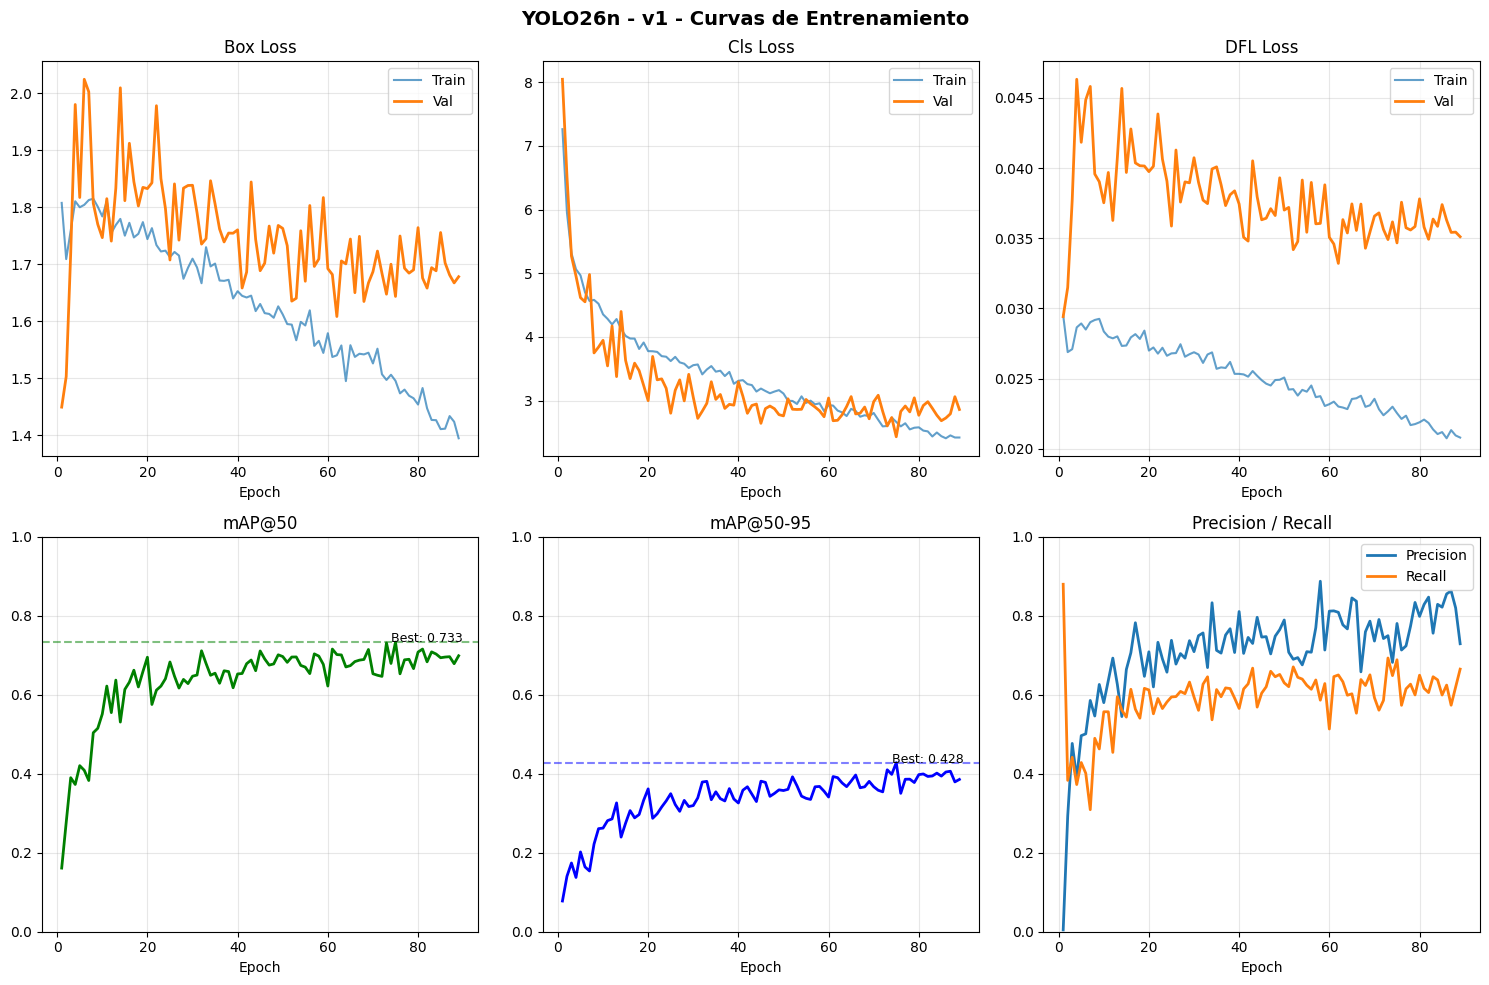

✅ Gráfico guardado en: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/reports/yolo26n_v1/yolo26n_v1_training_curves.png


In [11]:
# ============================================================================
# SECCIÓN 7: EXTRACCIÓN Y VISUALIZACIÓN DE MÉTRICAS
# ============================================================================

# Extraer métricas del entrenamiento
if RESULTS_DIR and safe_exists(RESULTS_DIR):
    history_df = extract_yolo_metrics(
        results_dir=RESULTS_DIR,
        logs_dir=str(LOGS_DIR),
        version_tag=EXPERIMENT_NAME,
        copy_best_model=True,
    )
    
    if history_df is not None:
        print("\n📊 Métricas extraídas exitosamente")
        print(f"   Épocas completadas: {len(history_df)}")
        
        # Obtener mejores métricas
        best_metrics = get_best_metrics(history_df)
        print("\n🏆 Mejores métricas:")
        for key, value in best_metrics.items():
            if "epoch" not in key:
                print(f"   {key}: {value:.4f}")
        
        # Graficar curvas de entrenamiento
        plot_path = str(REPORTS_DIR / f"{EXPERIMENT_NAME}_training_curves.png")
        plot_yolo_history(
            df=history_df,
            save_path=plot_path,
            title=f"YOLO26n - {VERSION} - Curvas de Entrenamiento",
            show=True,
        )
    else:
        print("⚠️ No se pudieron extraer las métricas")
else:
    print("⚠️ Directorio de resultados no encontrado")
    print("   Si el entrenamiento se interrumpió, verificar logs/")

## 8. Evaluación en Test Set

🔄 Cargando mejor modelo: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/yolo26n_v1/weights/best.pt
🔄 Cargando modelo: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/yolo26n_v1/weights/best.pt
✅ Modelo cargado: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/yolo26n_v1/weights/best.pt

📋 RESUMEN DEL MODELO YOLO26
🎯 Tarea: detect
📦 Clases: 2
   ['footpath', 'obstacle']
📊 Parámetros totales: 2.50M
📊 Parámetros entrenables: 0.00M

💾 Tamaño estimado del modelo:
   FP32: 9.55 MB
   FP16: 4.78 MB
   INT8: 2.39 MB
   ⚠️ Ajustado para ESP32-S3 - considerar optimizaciones


🔍 Evaluando en Test Set (PyTorch)...

🔍 Evaluando modelo en split: test
Ultralytics 8.4.9 🚀 Python-3.10.19 torch-2.5.1 CPU (Apple M1)
YOLO26n summary (fused): 122 layers, 2,375,226 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 37.9±21.6 MB/s, size: 7.7 KB)
val: Scanning /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/datasets/yolo26/labels/test... 84 images, 13 backgrounds,

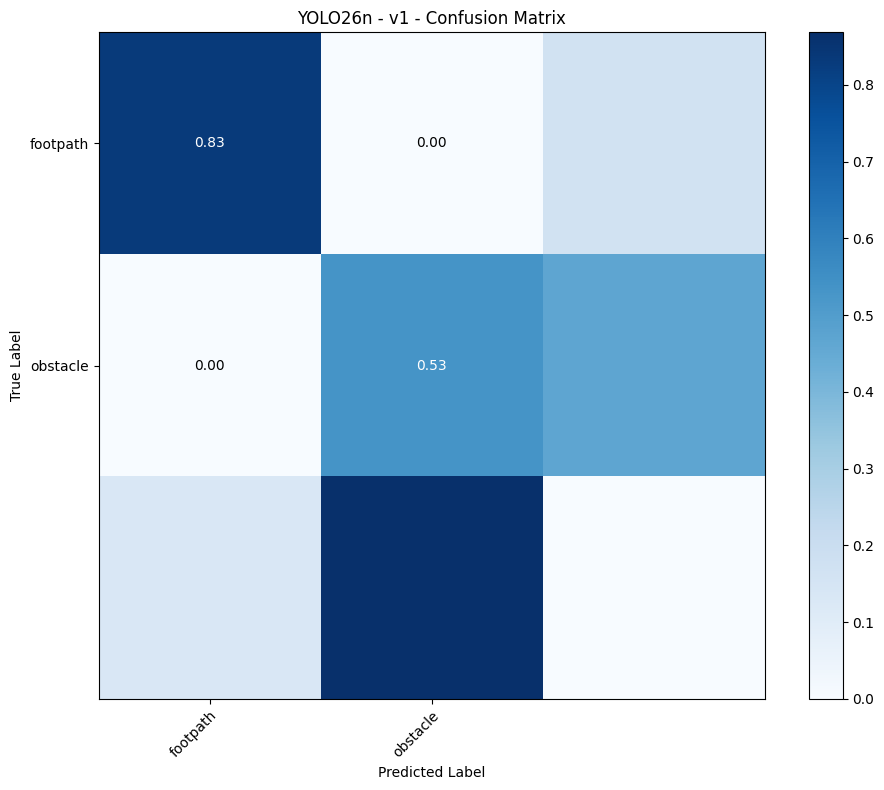

✅ Confusion matrix guardada en: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/reports/yolo26n_v1/yolo26n_v1_confusion_matrix.png


In [12]:
# ============================================================================
# SECCIÓN 8: EVALUACIÓN EN TEST SET
# ============================================================================

# Cargar mejor modelo y evaluar en test set
BEST_MODEL_PATH = str(LOGS_DIR / EXPERIMENT_NAME / "weights" / "best.pt")

if safe_exists(BEST_MODEL_PATH):
    print(f"🔄 Cargando mejor modelo: {BEST_MODEL_PATH}")
    
    # Cargar modelo
    model = load_yolo26_model(BEST_MODEL_PATH)
    
    if model:
        # Mostrar información del modelo
        print_model_summary(model)
        
        # Evaluar en test set
        print("\n🔍 Evaluando en Test Set (PyTorch)...")
        eval_results_pytorch = evaluate_model(
            model=model,
            data_yaml=DATA_YAML,
            split="test",
            imgsz=IMGSZ,
            conf_threshold=CONF_THRESHOLD,
            iou_threshold=IOU_THRESHOLD,
            end2end=True,  # NMS-free para YOLO26
            verbose=True,
        )
        
        if eval_results_pytorch:
            # Guardar confusion matrix
            if eval_results_pytorch.confusion_matrix is not None:
                cm_path = str(REPORTS_DIR / f"{EXPERIMENT_NAME}_confusion_matrix.png")
                plot_confusion_matrix(
                    confusion_matrix=eval_results_pytorch.confusion_matrix,
                    class_names=CLASS_NAMES,
                    save_path=cm_path,
                    title=f"YOLO26n - {VERSION} - Confusion Matrix",
                    normalize=True,
                    show=True,
                )
        else:
            print("⚠️ Error en evaluación")
else:
    print(f"❌ Modelo no encontrado: {BEST_MODEL_PATH}")

🖼️ Visualizando predicciones en imágenes de test...
   📂 Directorio: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/datasets/yolo26/images/test
   🎯 Umbral confianza: 0.25
   💡 YOLO26 es NMS-free (end-to-end inference)
✅ Visualización guardada en: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/reports/yolo26n_v1/yolo26n_v1_predictions_grid.png


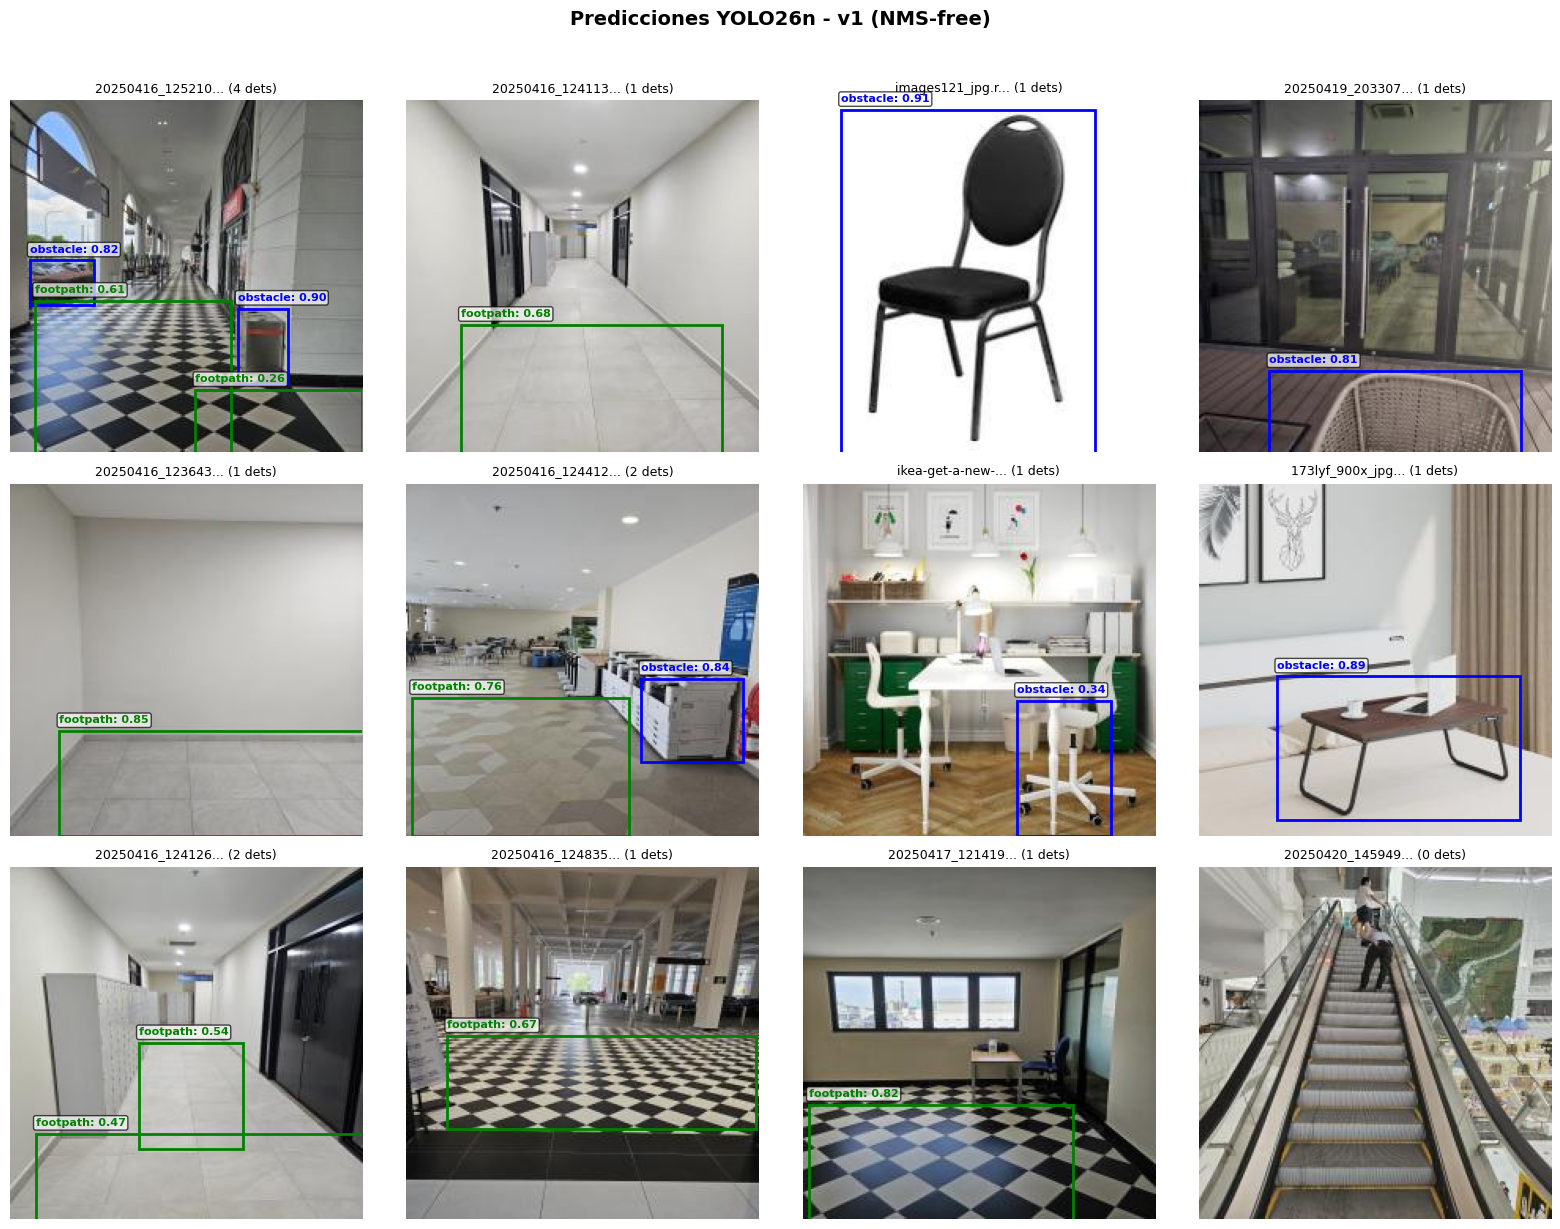

✅ Predicciones visualizadas (imágenes aleatorias del test set)


In [13]:
# ============================================================================
# SECCIÓN 8B: VISUALIZACIÓN DE PREDICCIONES EN TEST SET
# ============================================================================

# Visualizar predicciones en imágenes aleatorias del test set
# YOLO26 es NMS-free (end-to-end), por lo que no requiere post-procesado

from src_yolo import visualize_yolo_predictions_grid

if model is not None:
    # Directorio de imágenes de test
    test_images_dir = str(YOLO_DATASET_DIR / "images" / "test")
    
    print("🖼️ Visualizando predicciones en imágenes de test...")
    print(f"   📂 Directorio: {test_images_dir}")
    print(f"   🎯 Umbral confianza: {CONF_THRESHOLD}")
    print(f"   💡 YOLO26 es NMS-free (end-to-end inference)")
    
    fig = visualize_yolo_predictions_grid(
        model=model,
        images_dir=test_images_dir,
        class_names=CLASS_NAMES,
        imgsz=IMGSZ,
        num_samples=12,
        conf_threshold=CONF_THRESHOLD,
        random_seed=None,  # None = selección aleatoria cada vez
        save_path=str(REPORTS_DIR / f"{EXPERIMENT_NAME}_predictions_grid.png"),
        title=f"Predicciones YOLO26n - {VERSION} (NMS-free)",
        max_cols=4,
    )
    
    plt.show()
    print("✅ Predicciones visualizadas (imágenes aleatorias del test set)")
else:
    print("⚠️ Modelo no disponible para visualización")

## 9. Exportación a TFLite INT8

In [14]:
# ============================================================================
# SECCIÓN 9: EXPORTACIÓN A TFLITE INT8
# ============================================================================

# Exportar modelo a TFLite con cuantización INT8
# YOLO26 es DFL-free, lo que mejora la calidad de cuantización

TFLITE_OUTPUT_DIR = str(MODELS_DIR / "tflite")

if safe_exists(BEST_MODEL_PATH):
    # Estimar tamaño antes de exportar
    print("📊 Estimación de tamaño del modelo:")
    estimate_model_size(BEST_MODEL_PATH)
    
    print("\n🔄 Exportando a TFLite INT8...")
    print("   💡 YOLO26 es DFL-free → mejor cuantización INT8")
    print("   💡 End-to-end export → inferencia NMS-free")
    
    tflite_path = export_tflite_int8(
        model_path=BEST_MODEL_PATH,
        output_dir=TFLITE_OUTPUT_DIR,
        data_yaml=DATA_YAML,
        imgsz=IMGSZ,
        end2end=True,  # NMS-free
    )
    
    if tflite_path:
        TFLITE_MODEL_PATH = tflite_path
        print(f"\n✅ Modelo TFLite exportado: {TFLITE_MODEL_PATH}")
        
        # Verificar modelo exportado
        verification = verify_tflite_model(TFLITE_MODEL_PATH, imgsz=IMGSZ)
        
        if verification.get("valid"):
            print("\n✅ Verificación exitosa:")
            print(f"   Input shape: {verification.get('input_shape')}")
            print(f"   Output shapes: {verification.get('output_shapes')}")
            print(f"   Inference time: {verification.get('inference_time_ms', 0):.2f} ms")
    else:
        print("❌ Error en exportación TFLite")
        TFLITE_MODEL_PATH = None
else:
    print(f"❌ Modelo PyTorch no encontrado: {BEST_MODEL_PATH}")
    TFLITE_MODEL_PATH = None

📊 Estimación de tamaño del modelo:

📊 Estimación de tamaño del modelo:
   PyTorch: 14.78 MB
   FP32 TFLite: ~2.40 MB
   FP16 TFLite: ~1.20 MB
   INT8 TFLite: ~0.60 MB
   ESP32-S3: ✅ Compatible

🔄 Exportando a TFLite INT8...
   💡 YOLO26 es DFL-free → mejor cuantización INT8
   💡 End-to-end export → inferencia NMS-free

🔄 Exportando modelo a TFLite...
   📥 Entrada: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/yolo26n_v1/weights/best.pt
   📐 Tamaño: 224x224
   🔢 Cuantización: INT8
   🎯 End-to-end (NMS-free): True
   📊 Datos calibración: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/datasets/yolo26/data.yaml
Ultralytics 8.4.9 🚀 Python-3.10.19 torch-2.5.1 CPU (Apple M1)
YOLO26n summary (fused): 122 layers, 2,375,226 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from '/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/yolo26n_v1/weights/best.pt' with input shape (1, 3, 224, 224) BCHW and output shape(s) (1, 300, 6) (14.8 MB)

TensorFlow SavedModel: starting export with tens

I0000 00:00:1770239644.377648  289851 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1770239644.378918  289851 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Saved artifact at '/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/yolo26n_v1/weights/best_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 224, 224, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(shape=(1, 300, 6), dtype=tf.float32, name=None)
Captures:
  5200792032: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  5200791680: TensorSpec(shape=(3, 3, 3, 16), dtype=tf.float32, name=None)
  5200798016: TensorSpec(shape=(16,), dtype=tf.float32, name=None)
  5200799072: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  5200802592: TensorSpec(shape=(3, 3, 16, 32), dtype=tf.float32, name=None)
  5220225920: TensorSpec(shape=(32,), dtype=tf.float32, name=None)
  5220235424: TensorSpec(shape=(1, 1, 32, 32), dtype=tf.float32, name=None)
  5220234896: TensorSpec(shape=(32,), dtype=tf.float32, name=None)
  5220424112: TensorSpec(shape=(4,), dtype=tf.int64, name=None)
  5220428336: Te

I0000 00:00:1770239653.374964  289851 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1770239653.375573  289851 single_machine.cc:374] Starting new session
I0000 00:00:1770239653.376513  289851 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1770239653.376521  289851 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
W0000 00:00:1770239653.928487  289851 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1770239653.928499  289851 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1770239654.522265  289851 devices.cc:76] Number of eligible GPUs (core count >= 8, com

W0000 00:00:1770239657.773732  289851 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1770239657.773748  289851 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1770239657.802087  289851 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
fully_quantize: 0, inference_type: 6, input_inference_type: FLOAT32, output_inference_type: FLOAT32
W0000 00:00:1770239674.471824  289851 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1770239674.471843  289851 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
W0000 00:00:1770239690.816573  289851 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1770239690.816593  289851 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
W0000 00:00:1770239721.834752  289851 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_for

TensorFlow SavedModel: export success ✅ 111.0s, saved as '/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/yolo26n_v1/weights/best_saved_model' (31.1 MB)

TensorFlow Lite: starting export with tensorflow 2.19.1...
TensorFlow Lite: export success ✅ 0.0s, saved as '/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/yolo26n_v1/weights/best_saved_model/best_int8.tflite' (2.5 MB)

Export complete (111.1s)
Results saved to /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/yolo26n_v1/weights
Predict:         yolo predict task=detect model=/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/yolo26n_v1/weights/best_saved_model/best_int8.tflite imgsz=224 int8
Validate:        yolo val task=detect model=/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/yolo26n_v1/weights/best_saved_model/best_int8.tflite imgsz=224 data=/Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/datasets/yolo26/data.yaml int8 
Visualize:       https://netron.app

✅ Exportación completada en 111.1s
   📁 Modelo: /Users/a

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## 10. Comparación PyTorch vs TFLite

In [15]:
# ============================================================================
# SECCIÓN 10: COMPARACIÓN PYTORCH VS TFLITE
# ============================================================================

# Comparación exhaustiva entre PyTorch y TFLite INT8
# Métricas calculadas:
#   - Tiempos de inferencia y speedup
#   - Conteo de detecciones (filtradas por confianza)
#   - Agreement rate (% de detecciones coincidentes via IoU)
#   - IoU estadísticas entre detecciones matched
#   - Comparación de confianzas (correlación, diferencia media)
#   - Métricas por clase

# Nota: Usa CONF_THRESHOLD e IOU_THRESHOLD definidos en Sección 2

if TFLITE_MODEL_PATH and safe_exists(TFLITE_MODEL_PATH):
    import cv2
    
    # Cargar imágenes de test para comparación
    test_images_dir = YOLO_DATASET_DIR / "images" / "test"
    test_images = []
    
    if test_images_dir.exists():
        # Usar todas las imágenes de test para comparación más robusta
        image_files = sorted([f for f in test_images_dir.iterdir() 
                             if f.suffix.lower() in ['.jpg', '.jpeg', '.png']])
        
        print(f"📂 Cargando {len(image_files)} imágenes de test...")
        for img_file in image_files:
            img = cv2.imread(str(img_file))
            if img is not None:
                # Resize to model input size
                img_resized = cv2.resize(img, (IMGSZ, IMGSZ))
                test_images.append(img_resized)
    
    if test_images:
        print(f"🔄 Comparando PyTorch vs TFLite con {len(test_images)} imágenes...")
        print(f"   Conf threshold: {CONF_THRESHOLD}")
        print(f"   IoU threshold:  {IOU_THRESHOLD}")
        
        comparison = compare_keras_vs_tflite(
            keras_model=model,
            tflite_path=TFLITE_MODEL_PATH,
            test_images=test_images,
            class_names=CLASS_NAMES,
            imgsz=IMGSZ,
            conf_threshold=CONF_THRESHOLD,
            iou_threshold=IOU_THRESHOLD,
        )
        # La función ya imprime un resumen detallado
    else:
        print("⚠️ No se encontraron imágenes de test para comparación")
        comparison = None
else:
    print("⚠️ Modelo TFLite no disponible para comparación")
    comparison = None

📂 Cargando 84 imágenes de test...
🔄 Comparando PyTorch vs TFLite con 84 imágenes...
   Conf threshold: 0.25
   IoU threshold:  0.5

🔄 Ejecutando inferencia PyTorch...
🔄 Ejecutando inferencia TFLite...

📊 COMPARACIÓN PYTORCH vs TFLITE

⏱️ Tiempos de inferencia:
   PyTorch: 16.75 ms/img
   TFLite:  4.80 ms/img
   Speedup: 3.49x

🔢 Detecciones (conf >= 0.25):
   PyTorch: 131 (1.6/img)
   TFLite:  16820 (200.2/img)

🎯 Concordancia (IoU >= 0.5):
   Agreement rate: 0.0%
   Matched: 0
   Unmatched PyTorch: 131
   Unmatched TFLite: 16820

📋 Concordancia por clase:
   footpath: Py=61, TF=53, Agreement=0.0%
   obstacle: Py=70, TF=16767, Agreement=0.0%


## 11. Guardado de Resultados del Experimento

In [16]:
# ============================================================================
# SECCIÓN 11: GUARDADO DE RESULTADOS DEL EXPERIMENTO
# ============================================================================

from src_yolo.utils_io import safe_filesize_mb

# Crear configuración del experimento
experiment_config = Yolo26ExperimentConfig(
    name=EXPERIMENT_NAME,
    description=DESCRIPTION,
    model=f"{MODEL_VARIANT}.pt",
    imgsz=IMGSZ,
    epochs=train_config.epochs,
    patience=train_config.patience,
    batch=train_config.batch,
    optimizer=train_config.optimizer,
    lr0=train_config.lr0,
    lrf=train_config.lrf,
    cos_lr=train_config.cos_lr,
    mosaic=train_config.mosaic,
    mixup=train_config.mixup,
    close_mosaic=train_config.close_mosaic,
    box=train_config.box,
    cls=train_config.cls,
    num_classes=NUM_CLASSES,
    class_names=CLASS_NAMES,
    end2end=True,
    conf_threshold=CONF_THRESHOLD,
    iou_threshold=IOU_THRESHOLD,
    data_yaml=DATA_YAML,
    project_dir=str(LOGS_DIR),
)

# Crear resultados del experimento
experiment_results = Yolo26ExperimentResults()

# Métricas de entrenamiento (si existen)
if 'best_metrics' in dir():
    experiment_results.best_epoch = best_metrics.get('best_mAP50_epoch', 0)

# Métricas de evaluación PyTorch (si existen)
if 'eval_results_pytorch' in dir() and eval_results_pytorch:
    # Métricas principales
    experiment_results.map50_keras = eval_results_pytorch.map50
    experiment_results.map50_95_keras = eval_results_pytorch.map50_95
    experiment_results.precision_keras = eval_results_pytorch.precision
    experiment_results.recall_keras = eval_results_pytorch.recall
    experiment_results.f1_keras = eval_results_pytorch.f1_score
    
    # Métricas por clase
    experiment_results.per_class_ap50_keras = eval_results_pytorch.per_class_ap50 or {}
    experiment_results.per_class_precision_keras = getattr(eval_results_pytorch, 'per_class_precision', {}) or {}
    experiment_results.per_class_recall_keras = getattr(eval_results_pytorch, 'per_class_recall', {}) or {}
    
    # Matriz de confusión (convertir np.ndarray a lista para JSON)
    if eval_results_pytorch.confusion_matrix is not None:
        experiment_results.confusion_matrix = eval_results_pytorch.confusion_matrix.tolist()
        # Guardar también el path de la imagen de la matriz
        cm_image_path = str(REPORTS_DIR / f"{EXPERIMENT_NAME}_confusion_matrix.png")
        if safe_exists(cm_image_path):
            experiment_results.confusion_matrix_path = cm_image_path
    
    # Estadísticas de evaluación
    experiment_results.total_images = getattr(eval_results_pytorch, 'total_images', 0)
    experiment_results.total_predictions = getattr(eval_results_pytorch, 'total_predictions', 0)
    experiment_results.total_ground_truth = getattr(eval_results_pytorch, 'total_ground_truth', 0)
    experiment_results.inference_time_pytorch_ms = getattr(eval_results_pytorch, 'avg_inference_time_ms', 0.0)

# Comparación PyTorch vs TFLite (si existe)
if 'comparison' in dir() and comparison:
    # Métricas básicas de timing
    experiment_results.comparison_speedup = comparison.get('speedup', 0.0)
    experiment_results.inference_time_tflite_ms = comparison.get('tflite_time_ms', 0.0)
    if experiment_results.inference_time_pytorch_ms == 0.0:
        experiment_results.inference_time_pytorch_ms = comparison.get('keras_time_ms', 0.0)
    
    # Conteo de detecciones
    experiment_results.comparison_keras_detections = comparison.get('keras_detections', 0)
    experiment_results.comparison_tflite_detections = comparison.get('tflite_detections', 0)
    experiment_results.comparison_keras_detections_per_image = comparison.get('keras_detections_per_image', 0.0)
    experiment_results.comparison_tflite_detections_per_image = comparison.get('tflite_detections_per_image', 0.0)
    
    # Métricas de concordancia (agreement)
    experiment_results.comparison_agreement_rate = comparison.get('agreement_rate', 0.0)
    experiment_results.comparison_matched_detections = comparison.get('matched_detections', 0)
    experiment_results.comparison_unmatched_keras = comparison.get('unmatched_keras', 0)
    experiment_results.comparison_unmatched_tflite = comparison.get('unmatched_tflite', 0)
    
    # Estadísticas de IoU entre detecciones coincidentes
    experiment_results.comparison_mean_iou = comparison.get('mean_iou', 0.0)
    experiment_results.comparison_min_iou = comparison.get('min_iou', 0.0)
    experiment_results.comparison_max_iou = comparison.get('max_iou', 0.0)
    experiment_results.comparison_std_iou = comparison.get('std_iou', 0.0)
    
    # Comparación de confianzas
    experiment_results.comparison_mean_conf_keras = comparison.get('mean_conf_keras', 0.0)
    experiment_results.comparison_mean_conf_tflite = comparison.get('mean_conf_tflite', 0.0)
    experiment_results.comparison_mean_conf_diff = comparison.get('mean_conf_diff', 0.0)
    experiment_results.comparison_conf_correlation = comparison.get('conf_correlation', 0.0)
    
    # Métricas por clase
    experiment_results.comparison_per_class_agreement = comparison.get('per_class_agreement', {})
    experiment_results.comparison_per_class_detections_keras = comparison.get('per_class_detections_keras', {})
    experiment_results.comparison_per_class_detections_tflite = comparison.get('per_class_detections_tflite', {})

# Paths y tamaños
if safe_exists(BEST_MODEL_PATH):
    experiment_results.best_model_path = BEST_MODEL_PATH
    experiment_results.pytorch_model_size_mb = safe_filesize_mb(BEST_MODEL_PATH) or 0.0

if TFLITE_MODEL_PATH and safe_exists(TFLITE_MODEL_PATH):
    experiment_results.tflite_model_path = TFLITE_MODEL_PATH
    experiment_results.tflite_int8_size_mb = safe_filesize_mb(TFLITE_MODEL_PATH) or 0.0

# Historia CSV
history_csv_path = str(LOGS_DIR / f"{EXPERIMENT_NAME}_history.csv")
if safe_exists(history_csv_path):
    experiment_results.history_csv_path = history_csv_path

# Crear objeto de experimento completo
experiment = Yolo26Experiment(
    config=experiment_config,
    results=experiment_results,
    status="completed",
    notes=EXPERIMENT_NOTES,
)

# Guardar experimento
experiment_file = save_experiment(
    experiment=experiment,
    experiments_dir=str(EXPERIMENTS_DIR),
)

# Mostrar resumen
print(experiment.summary())

✅ Experimento guardado: /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/experiments/yolo26n_v1_20260204_161835.json
🔬 EXPERIMENTO: yolo26n_v1
📝 Descripción: Primer entrenamiento real YOLO26n para ESP32-S3.
Objetivo: Superar MobileNetV3 baseline (mAP@50=0.606).
Configuración optimizada basada en análisis de dataset:
- obstacle: 68% de anotaciones, 20% objetos pequeños
- footpath: 32% de anotaciones, 62% objetos grandes
- Desbalance 2.1:1 obstacle/footpath
📅 Timestamp: 20260204_161835
📊 Status: completed

⚙️ Configuración:
   Modelo: yolo26n.pt | Tamaño: 224x224
   Épocas: 150 | Batch: 16
   Optimizer: MuSGD | LR: 0.01
   Mosaic: 1.0 | Mixup: 0.15
   End-to-end: True

📊 Resultados:
   mAP@50 (PyTorch): 0.6231
   mAP@50 (TFLite):  0.0000
   Gap:              0.6231

   Precision: 0.6716
   Recall:    0.5303
   F1-Score:  0.5926

   Tamaño TFLite INT8: 2.54 MB
   Tiempo inferencia:  4.80 ms

📝 Notas: Análisis del problema:
1. Dataset: 2,432 anotaciones (obstacle:1648, footpath:784)
2. 

## 12. Comparación de Experimentos

In [17]:
# ============================================================================
# SECCIÓN 12: COMPARACIÓN DE EXPERIMENTOS
# ============================================================================

from src_yolo import print_experiments_table, export_experiments_csv

# Cargar todos los experimentos guardados
all_experiments = load_all_experiments(str(EXPERIMENTS_DIR))

if all_experiments:
    # Mostrar tabla comparativa
    print_experiments_table(all_experiments)
    
    # Exportar comparación a CSV
    comparison_csv = str(LOGS_DIR / "yolo26_experiments_comparison.csv")
    export_experiments_csv(all_experiments, comparison_csv)
    
    # Crear DataFrame para análisis
    comparison_df = compare_experiments(all_experiments, sort_by="map50_keras", ascending=False)
    
    if not comparison_df.empty:
        print("\n📊 Top 5 experimentos por mAP@50:")
        display_cols = ["name", "map50_keras", "precision_keras", "recall_keras", "tflite_size_mb"]
        display_cols = [c for c in display_cols if c in comparison_df.columns]
        print(comparison_df[display_cols].head(5).to_string(index=False))
else:
    print("ℹ️ No hay experimentos previos para comparar")

📦 Cargados 10 experimentos de /Users/admin/Documents/TFM_UNIR/02_ING_MODELOS/logs/experiments

📊 COMPARACIÓN DE EXPERIMENTOS YOLO26
Name                       mAP@50 PT  mAP@50 TF      Gap     Prec      Rec  Size MB
----------------------------------------------------------------------------------------------------
yolo26n_v1                    0.6231     0.0000   0.6231   0.6716   0.5303     2.54
MBNTv3_ssdlite_v3             0.6059     0.5744   0.0315   0.2036   0.4188     0.00
MBNTv3L_ssdlite_v6            0.5757     0.5766   0.0009   0.3580   0.3625     0.00
MBNTv3_ssdlite_v1             0.5675     0.5509   0.0165   0.2674   0.4313     0.00
MBNTv3_ssdlite_v7             0.5591     0.5437   0.0154   0.4238   0.4000     0.00
MBNTv3_ssdlite_v5             0.5492     0.4705   0.0787   0.4071   0.3563     0.00
MBNTv3_ssdlite_v4             0.4523     0.4501   0.0022   0.6933   0.3250     0.00
MBNTv3_ssdlite_v2             0.4058     0.3624   0.0435   0.6863   0.2188     0.00
yolo26n_v0 

---

## 🎯 Resumen Final

Este notebook ha completado el pipeline de entrenamiento YOLO26n:

1. ✅ **Setup**: Configuración de paths y imports
2. ✅ **Experimento**: Definición de versión y parámetros
3. ✅ **Dataset**: Conversión COCO → YOLO
4. ✅ **Análisis**: Distribución de clases y weights
5. ✅ **Config**: Hiperparámetros YOLO26 optimizados
6. ✅ **Training**: Entrenamiento con MuSGD y end-to-end
7. ✅ **Métricas**: Extracción y visualización
8. ✅ **Evaluación**: Métricas en test set
9. ✅ **Export**: TFLite INT8 para ESP32-S3
10. ✅ **Comparación**: PyTorch vs TFLite
11. ✅ **Guardado**: Experimento serializado
12. ✅ **Histórico**: Comparación de experimentos

### Próximos pasos:
- Ajustar hiperparámetros según resultados
- Probar variantes (yolo26s, yolo26m) si hay presupuesto de memoria
- Deployment en ESP32-S3 con ESP-IDF